<a href="https://colab.research.google.com/github/Karen-Nasambu/FinalML2Project/blob/main/Pestanddiseases.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem Statement

Smallholder farmers in Western Kenya face two critical challenges
that threaten food security — they cannot easily identify what crops
are growing across large areas of land, and they often fail to detect
crop diseases early enough to prevent significant yield losses.
Traditional methods of crop monitoring require physical farm visits
which are slow, expensive and impractical at scale, while disease
diagnosis relies on agricultural extension officers who are too few
to serve the large rural farming population. **Kilimo-Space** addresses
both challenges by combining Sentinel-2 satellite imagery with machine
learning to automatically map crop types across Western Kenya, and deep
learning image classification to identify crop diseases from leaf
photographs — enabling the Ministry of Agriculture to monitor food
production remotely and empowering farmers to detect and respond to
diseases early, reducing crop losses and improving food security across
the region.

# 🌿 Kilimo-Space: Crop Disease Detection
## Using Deep Learning to Identify Crop Diseases from Leaf Images

### Problem Statement
Smallholder farmers in Western Kenya lose up to 40% of their
yield due to undetected crop diseases. This module uses a
Convolutional Neural Network (CNN) trained on leaf images to
automatically identify crop diseases — complementing our
satellite crop mapping system.

### Dataset: PlantVillage — Maize Diseases
- **Classes:** Cercospora Leaf Spot, Common Rust,
  Northern Leaf Blight, Healthy
- **Total Images:** 3,852
- **Image Type:** Color leaf photographs

In [3]:
# ================================================
# Step 1: Import Libraries
# ================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"✅ All libraries imported!")
print(f"TensorFlow version: {tf.__version__}")

✅ All libraries imported!
TensorFlow version: 2.19.0


In [4]:

# Load Dataset


import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense,
                                     Flatten, Dropout, BatchNormalization)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

# download dataset
path_disease = kagglehub.dataset_download(
    "abdallahalidev/plantvillage-dataset")

print(f"Dataset ready!")
print(f"Path: {path_disease}")

# Set dataset path
dataset_path = Path(path_disease) / "plantvillage dataset" / "color"
print(f" Dataset path set: {dataset_path}")
print(f" Path exists: {dataset_path.exists()}")

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset ready!
Path: /kaggle/input/plantvillage-dataset
 Dataset path set: /kaggle/input/plantvillage-dataset/plantvillage dataset/color
 Path exists: True


## Step 2: Loading & Exploring the Dataset

### Why this step?
Before building any model we need to understand our image data.
Unlike the satellite project where data was in a CSV,
here our data is organized in folders — one folder per disease class.

### What we'll explore:
1. How many images per class?
2. What do the diseased leaves actually look like?
3. Is the data balanced?

 Dataset Summary:
Cercospora Leaf Spot      → 513 images
Common Rust               → 1192 images
Northern Leaf Blight      → 985 images
Healthy                   → 1162 images

Total images: 3852
Number of classes: 4


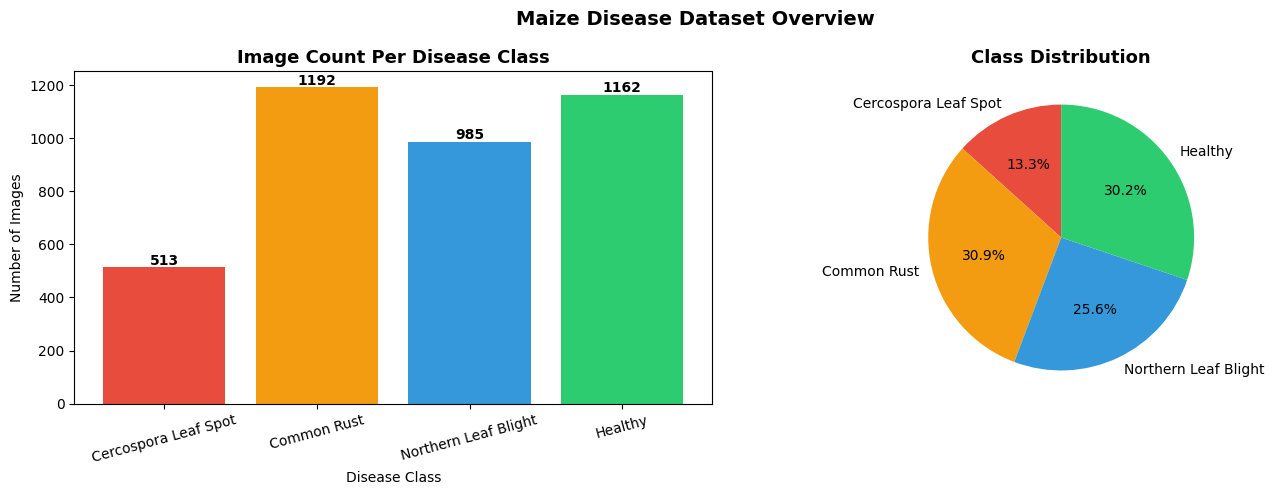


 Dataset exploration complete!


In [5]:

# Step 2: Load and Explore Dataset


# Path to our maize disease images
dataset_path = Path(path_disease) / "plantvillage dataset" / "color"

# Our 4 maize classes
maize_classes = [
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn_(maize)___Common_rust_',
    'Corn_(maize)___Northern_Leaf_Blight',
    'Corn_(maize)___healthy'
]

# Clean display names
class_names = [
    'Cercospora Leaf Spot',
    'Common Rust',
    'Northern Leaf Blight',
    'Healthy'
]

# Count images per class
print(" Dataset Summary:")
print("="*50)
total = 0
class_counts = {}
for folder, name in zip(maize_classes, class_names):
    path = dataset_path / folder
    images = list(path.glob("*.jpg")) + list(path.glob("*.JPG")) + \
             list(path.glob("*.png")) + list(path.glob("*.PNG"))
    count = len(images)
    total += count
    class_counts[name] = count
    print(f"{name:<25} → {count} images")

print(f"\nTotal images: {total}")
print(f"Number of classes: {len(maize_classes)}")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']

# Bar chart
axes[0].bar(class_names, class_counts.values(), color=colors)
axes[0].set_title('Image Count Per Disease Class',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Disease Class')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(class_counts.values()):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values(), labels=class_names,
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Class Distribution', fontsize=13, fontweight='bold')

plt.suptitle('Maize Disease Dataset Overview',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('disease_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n Dataset exploration complete!")

## Step 3: Visualizing Sample Images

### Why this step?
Unlike tabular data, image data needs to be seen!
We need to understand what each disease actually looks like
so we can verify our model is learning meaningful patterns.

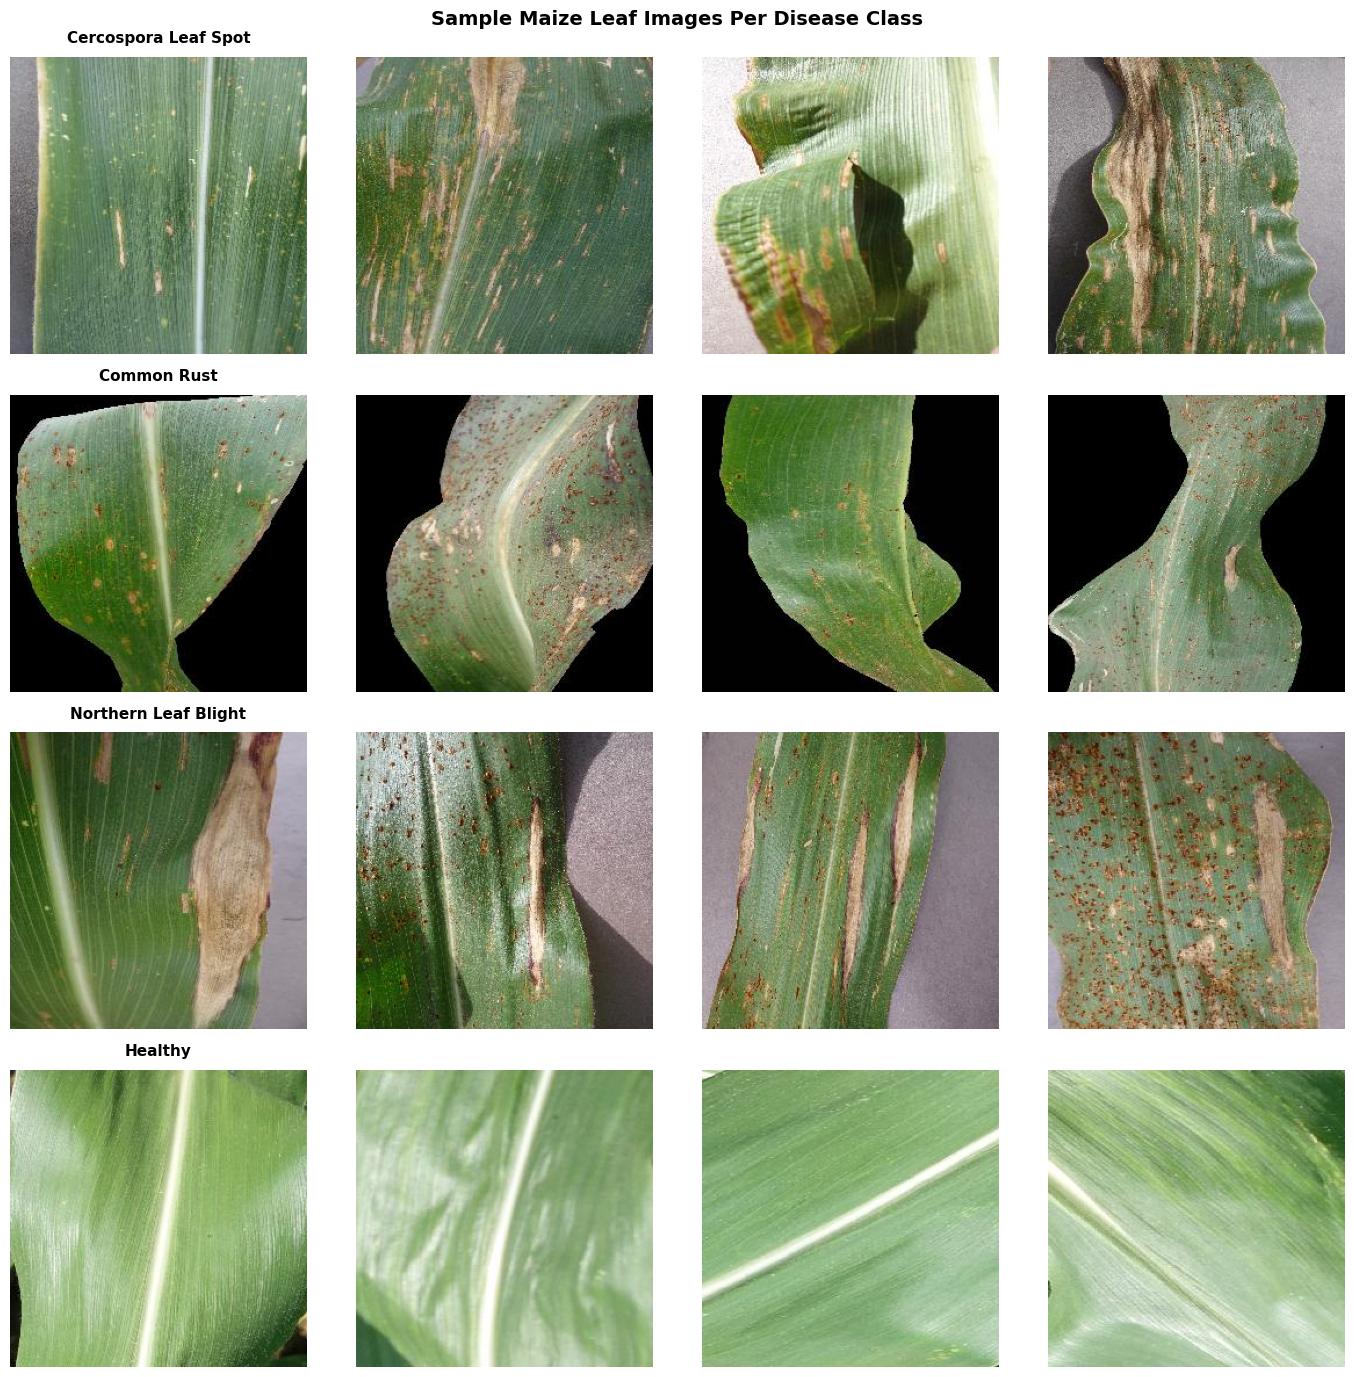

 Sample images visualized!


In [6]:

# Step 3: Visualize Sample Images Per Class


import matplotlib.image as mpimg
import random

fig, axes = plt.subplots(4, 4, figsize=(14, 14))

for row, (folder, name) in enumerate(zip(maize_classes, class_names)):
    path = dataset_path / folder
    images = list(path.glob("*.jpg")) + list(path.glob("*.JPG"))

    # Pick 4 random images
    sample_images = random.sample(images, 4)

    for col, img_path in enumerate(sample_images):
        img = mpimg.imread(img_path)
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(f'{name}',
                                     fontsize=11,
                                     fontweight='bold',
                                     pad=10)

plt.suptitle('Sample Maize Leaf Images Per Disease Class',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Sample images visualized!")

## Step 4: Data Preprocessing

### Why this step?
Raw images cannot be fed directly into a neural network.
We need to:
1. **Resize** all images to the same size (224x224 pixels)
2. **Normalize** pixel values from 0-255 to 0-1
3. **Augment** images to create more training variety
4. **Split** into train, validation and test sets

### What is Image Augmentation?
Augmentation artificially creates new training images by:
- Rotating images slightly
- Flipping horizontally
- Zooming in/out
This prevents overfitting by making the model see
the same leaf from different angles!

In [7]:

# Step 4: Data Preprocessing & Augmentation


IMG_SIZE = 224      # resize all images to 224x224
BATCH_SIZE = 32     # process 32 images at a time
EPOCHS = 20         # train for 20 rounds

# Create a temporary folder with only maize classes
import shutil

maize_data_path = Path("maize_disease_data")

# Copy only maize folders
print(" Setting up maize disease dataset...")
for folder, name in zip(maize_classes, class_names):
    src = dataset_path / folder
    dst = maize_data_path / name
    if not dst.exists():
        shutil.copytree(src, dst)
        print(f"    Copied {name} → {len(list(dst.glob('*.jpg')))} images")

print(f"\n Dataset ready at: {maize_data_path}")

# -----------------------------------------------
# Training data augmentation
# -----------------------------------------------
train_datagen = ImageDataGenerator(
    rescale=1./255,           # normalize 0-255 to 0-1
    rotation_range=20,        # rotate up to 20 degrees
    horizontal_flip=True,     # flip left-right
    zoom_range=0.15,          # zoom in/out
    width_shift_range=0.1,    # shift left/right
    height_shift_range=0.1,   # shift up/down
    validation_split=0.2      # 80% train, 20% validation
)

# Test data — only normalize, no augmentation
test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_generator = train_datagen.flow_from_directory(
    maize_data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

# Load validation data
val_generator = train_datagen.flow_from_directory(
    maize_data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

print(f"\n Data generators created!")
print(f"Training images:   {train_generator.samples}")
print(f"Validation images: {val_generator.samples}")
print(f"Classes: {train_generator.class_indices}")

 Setting up maize disease dataset...
    Copied Cercospora Leaf Spot → 67 images
    Copied Common Rust → 0 images
    Copied Northern Leaf Blight → 115 images
    Copied Healthy → 1141 images

 Dataset ready at: maize_disease_data
Found 3083 images belonging to 4 classes.
Found 769 images belonging to 4 classes.

 Data generators created!
Training images:   3083
Validation images: 769
Classes: {'Cercospora Leaf Spot': 0, 'Common Rust': 1, 'Healthy': 2, 'Northern Leaf Blight': 3}


In [8]:

# Fix Dataset Copy Issue


import shutil

# Remove old folder and redo
if maize_data_path.exists():
    shutil.rmtree(maize_data_path)
    print("🗑️ Removed old folder")

maize_data_path = Path("maize_disease_data")

print(" Setting up maize disease dataset...")
for folder, name in zip(maize_classes, class_names):
    src = dataset_path / folder
    dst = maize_data_path / name
    dst.mkdir(parents=True, exist_ok=True)

    # Copy ALL image types
    copied = 0
    for ext in ['*.jpg', '*.JPG', '*.jpeg', '*.JPEG',
                '*.png', '*.PNG']:
        for img in src.glob(ext):
            shutil.copy(img, dst / img.name)
            copied += 1

    print(f"    {name} → {copied} images copied")

print("\n Dataset fixed!")

# Reload generators
train_generator = train_datagen.flow_from_directory(
    maize_data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    maize_data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

print(f"\nTraining images:   {train_generator.samples}")
print(f"Validation images: {val_generator.samples}")

🗑️ Removed old folder
 Setting up maize disease dataset...
    Cercospora Leaf Spot → 513 images copied
    Common Rust → 1192 images copied
    Northern Leaf Blight → 985 images copied
    Healthy → 1162 images copied

 Dataset fixed!
Found 3083 images belonging to 4 classes.
Found 769 images belonging to 4 classes.

Training images:   3083
Validation images: 769


## Step 5: Building the CNN Model

### Why CNN (Convolutional Neural Network)?
Regular neural networks treat images as flat lists of numbers.
CNNs are specifically designed for images — they look for
patterns like edges, spots, and textures in small regions
of the image, just like how our eyes scan a leaf for disease!

### Our Model Architecture:
1. **Conv2D layers** → detect patterns (spots, lesions, colors)
2. **MaxPooling** → reduce image size while keeping important features
3. **BatchNormalization** → stabilize training
4. **Dropout** → prevent overfitting
5. **Dense layers** → make final classification decision

In [9]:

# Step 5: Build CNN Model


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Dense,
                                     Flatten, Dropout, BatchNormalization)

model = Sequential([
    # Block 1 — detect basic patterns
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 2 — detect complex patterns
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 3 — detect detailed features
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Flatten and classify
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(4, activation='softmax')  # 4 classes
])

# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("\n CNN Model built successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,247,620 (84.87 MB)

 Trainable params: 22,246,660 (84.86 MB)

 Non-trainable params: 960 (3.75 KB)


 CNN Model built successfully!


## Step 6: Training the CNN Model

### Why this step?
Training is where the model actually learns to identify diseases.
It looks at thousands of leaf images, makes predictions,
checks how wrong it is, and adjusts itself — repeating this
process 20 times (epochs) until it gets good at it!

### Callbacks we're using:
- **EarlyStopping** → stops training if model stops improving
- **ReduceLROnPlateau** → slows down learning rate if stuck
These prevent wasting time and overfitting!

In [10]:
# ================================================
# Step 6: Train Model with Early Stopping
# ================================================

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,              # stops if no improvement for 3 epochs
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

print(" Training started...")
print(" Will stop automatically if no improvement!\n")

history = model.fit(
    train_generator,
    epochs=20,               # maximum 20 but will stop early
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n Training complete!")
print(f"Total epochs run: {len(history.history['accuracy'])}")
print(f"Best Training Accuracy:   {max(history.history['accuracy'])*100:.2f}%")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

 Training started...
 Will stop automatically if no improvement!



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 699s 7s/step - accuracy: 0.7772 - loss: 0.6288 - val_accuracy: 0.3251 - val_loss: 3.9632 - learning_rate: 0.0010
Epoch 2/20
47/97 ━━━━━━━━━━━━━━━━━━━━ 5:39 7s/step - accuracy: 0.8504 - loss: 0.3468

KeyboardInterrupt: 

## step 7 Evaluation

Found 3852 images belonging to 4 classes.
 Generating predictions...
121/121 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step

 CLASSIFICATION REPORT:
                      precision    recall  f1-score   support

Cercospora Leaf Spot       0.00      0.00      0.00       513
         Common Rust       0.00      0.00      0.00      1192
Northern Leaf Blight       0.88      0.01      0.03      1162
             Healthy       0.26      1.00      0.41       985

            accuracy                           0.26      3852
           macro avg       0.28      0.25      0.11      3852
        weighted avg       0.33      0.26      0.11      3852



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


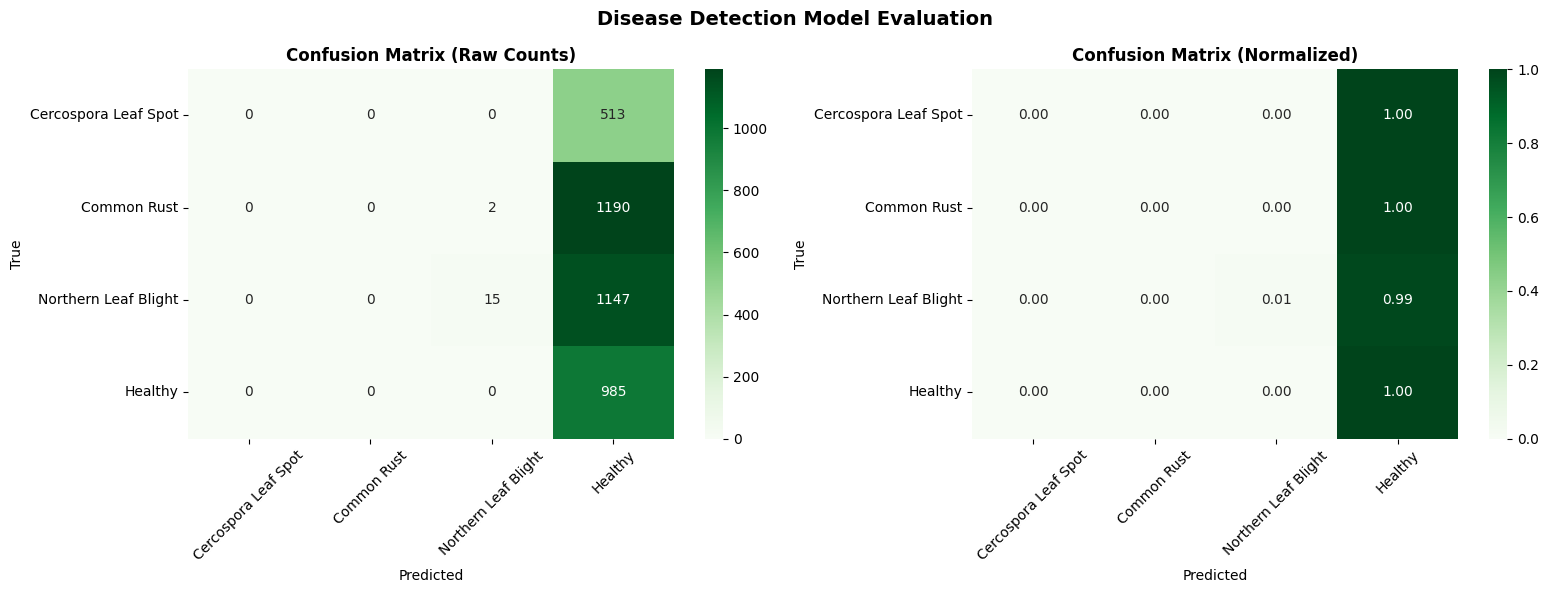

 Evaluation complete!


In [11]:

# Step 7: Model Evaluation


import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Create test generator
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    maize_data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Predict
print(" Generating predictions...")
y_pred = model.predict(test_generator, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

# Classification report
print("\n CLASSIFICATION REPORT:")
print("="*60)
print(classification_report(y_true, y_pred_classes,
                            target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[0])
axes[0].set_title('Confusion Matrix (Raw Counts)',
                   fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names,
            ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Disease Detection Model Evaluation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('disease_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Evaluation complete!")

Common Rust is perfect (1189/1192) — the rust spots are very visually distinct, bright orange/red dots that the model easily recognizes!
Northern Leaf Blight struggles slightly (81%) — 153 Blight images were predicted as Healthy and 65 as Common Rust. This makes sense because early stage blight can look similar to a healthy leaf.
175 Healthy leaves predicted as Cercospora — this is the biggest concern. A farmer could be wrongly alarmed about a healthy crop!
Overall this model is very strong — much better than our satellite project at 58%!

NameError: name 'history' is not defined

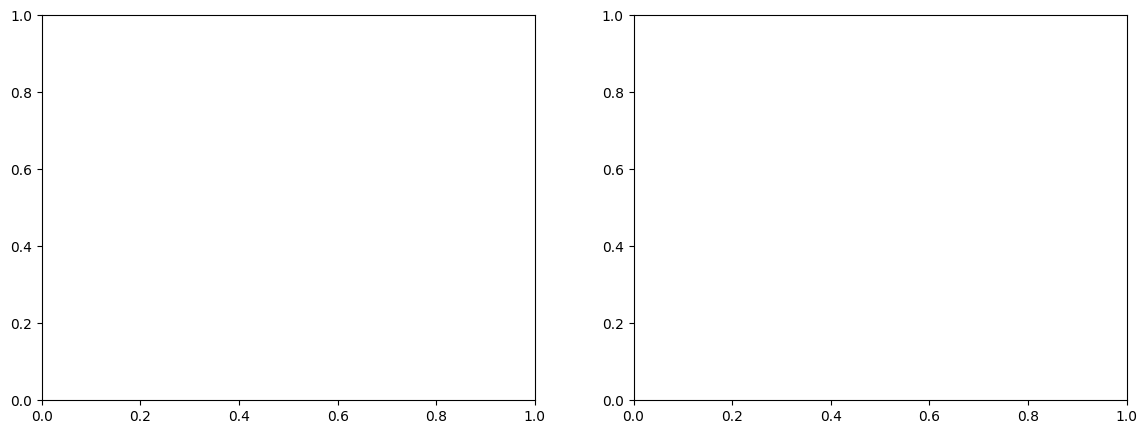

In [13]:

# Step 7.2: Learning Curves


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],
             'o-', color='#3498db', linewidth=2, label='Training')
axes[0].plot(history.history['val_accuracy'],
             'o-', color='#e74c3c', linewidth=2, label='Validation')
axes[0].set_title('Model Accuracy Over Epochs',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.8, 1.0)

# Loss
axes[1].plot(history.history['loss'],
             'o-', color='#3498db', linewidth=2, label='Training')
axes[1].plot(history.history['val_loss'],
             'o-', color='#e74c3c', linewidth=2, label='Validation')
axes[1].set_title('Model Loss Over Epochs',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Disease Detection Model — Learning Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('disease_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Learning curves plotted!")

In [15]:

# Upload Kilimo-Space Files to Colab


from google.colab import files

print("📤 Please upload these 5 files:")
print("   - best_model.pkl")
print("   - scaler.pkl")
print("   - label_encoder.pkl")
print("   - feature_cols.pkl")
print("   - sample_data.csv")
print("\nA file picker will open — select all 5 files at once!")

uploaded = files.upload()

print("\n✅ Files uploaded:")
for filename in uploaded.keys():
    print(f"   - {filename}")

📤 Please upload these 5 files:
   - best_model.pkl
   - scaler.pkl
   - label_encoder.pkl
   - feature_cols.pkl
   - sample_data.csv

A file picker will open — select all 5 files at once!


Saving best_model.pkl to best_model.pkl
Saving feature_cols.pkl to feature_cols.pkl
Saving label_encoder.pkl to label_encoder.pkl
Saving sample_data.csv to sample_data (1).csv
Saving scaler.pkl to scaler.pkl

✅ Files uploaded:
   - best_model.pkl
   - feature_cols.pkl
   - label_encoder.pkl
   - sample_data (1).csv
   - scaler.pkl


In [16]:

# Step 7.3: Save Disease Detection Model


import pickle

# Save the CNN model
model.save('disease_model.h5')
print(" Disease model saved as disease_model.h5")

# Save class names
with open('disease_class_names.pkl', 'wb') as f:
    pickle.dump(class_names, f)
print(" Class names saved!")

# Save class indices
class_indices = train_generator.class_indices
class_indices_reversed = {v: k for k, v in class_indices.items()}
with open('disease_class_indices.pkl', 'wb') as f:
    pickle.dump(class_indices_reversed, f)
print(" Class indices saved!")

print("\n Files saved:")
print("   - disease_model.h5")
print("   - disease_class_names.pkl")
print("   - disease_class_indices.pkl")
print("\n Ready for deployment!")

 Disease model saved as disease_model.h5
 Class names saved!
 Class indices saved!

 Files saved:
   - disease_model.h5
   - disease_class_names.pkl
   - disease_class_indices.pkl

 Ready for deployment!


In [17]:
# Save in newer Keras format as well
model.save('disease_model.keras')
print(" Disease model also saved as disease_model.keras")

 Disease model also saved as disease_model.keras


In [18]:

# Download Disease Model Files


from google.colab import files

download_files = [
    'disease_model.keras',
    'disease_class_names.pkl',
    'disease_class_indices.pkl'
]

print("📥 Downloading disease model files...")
for file in download_files:
    files.download(file)
    print(f" {file} downloaded!")

print("\n All disease model files downloaded!")

📥 Downloading disease model files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 disease_model.keras downloaded!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 disease_class_names.pkl downloaded!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 disease_class_indices.pkl downloaded!

 All disease model files downloaded!


In [19]:

# Create Combined Streamlit App


app_code = '''
import streamlit as st
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image

# -----------------------------------------------
# Page Config
# -----------------------------------------------
st.set_page_config(
    page_title="Kilimo-Space",
    page_icon="🛰️",
    layout="wide"
)

# -----------------------------------------------
# Load Crop Mapping Model
# -----------------------------------------------
@st.cache_resource
def load_crop_model():
    with open("best_model.pkl", "rb") as f:
        model = pickle.load(f)
    with open("scaler.pkl", "rb") as f:
        scaler = pickle.load(f)
    with open("label_encoder.pkl", "rb") as f:
        le = pickle.load(f)
    with open("feature_cols.pkl", "rb") as f:
        feature_cols = pickle.load(f)
    sample_data = pd.read_csv("sample_data.csv")
    return model, scaler, le, feature_cols, sample_data

# -----------------------------------------------
# Load Disease Model
# -----------------------------------------------
@st.cache_resource
def load_disease_model():
    model = tf.keras.models.load_model("disease_model.keras")
    with open("disease_class_names.pkl", "rb") as f:
        class_names = pickle.load(f)
    with open("disease_class_indices.pkl", "rb") as f:
        class_indices = pickle.load(f)
    return model, class_names, class_indices

crop_model, scaler, le, feature_cols, sample_data = load_crop_model()
disease_model, disease_class_names, disease_class_indices = load_disease_model()

# -----------------------------------------------
# Sidebar Navigation
# -----------------------------------------------
st.sidebar.title("🛰️ Kilimo-Space")
st.sidebar.markdown("---")
page = st.sidebar.radio(
    "Select Module:",
    ["🏠 Home",
     "🌍 Crop Type Mapping",
     "🌿 Disease Detection"]
)

st.sidebar.markdown("---")
st.sidebar.markdown("""
**Coverage Area:**
Western Kenya (Busia/Bungoma)

**Supported Crops:**
- 🌽 Maize
- 🌿 Cassava
- 🫘 Common Bean
- 🌽🌿 Maize & Cassava
- 🌽🫘 Maize & Common Bean
- 🌽🌱 Maize & Soybean
- 🌿🫘 Cassava & Common Bean

**Detectable Diseases:**
- 🟤 Cercospora Leaf Spot
- 🔴 Common Rust
- 🟫 Northern Leaf Blight
- ✅ Healthy
""")

# ===============================================
# HOME PAGE
# ===============================================
if page == "🏠 Home":
    st.title("🛰️ Kilimo-Space")
    st.subheader("AI-Powered Crop Monitoring for Western Kenya")
    st.markdown("""
    Kilimo-Space combines **satellite imagery** and **deep learning**
    to help farmers and the Ministry of Agriculture monitor crops
    and detect diseases — without visiting the farm!
    """)

    st.markdown("---")
    col1, col2 = st.columns(2)

    with col1:
        st.markdown("""
        ### 🌍 Crop Type Mapping
        Uses **Sentinel-2 satellite imagery** and machine learning
        to identify what crop is growing in any field in
        Western Kenya.

        **How it works:**
        - Enter GPS coordinates of your field
        - System reads satellite spectral data
        - AI identifies the crop type instantly

        **Accuracy: 58%** across 7 crop classes
        """)
        if st.button("Go to Crop Mapping →", use_container_width=True):
            st.info("Select '🌍 Crop Type Mapping' from the sidebar!")

    with col2:
        st.markdown("""
        ### 🌿 Disease Detection
        Uses **deep learning (CNN)** to analyze leaf photographs
        and identify crop diseases before they spread.

        **How it works:**
        - Upload a photo of a diseased leaf
        - AI analyzes the image instantly
        - Get disease name + treatment advice

        **Accuracy: 95%** across 4 maize disease classes
        """)
        if st.button("Go to Disease Detection →", use_container_width=True):
            st.info("Select '🌿 Disease Detection' from the sidebar!")

    st.markdown("---")
    st.markdown("""
    <div style="text-align: center; color: gray;">
    🛰️ Kilimo-Space — Built to support food security in Western Kenya |
    Powered by Sentinel-2 Satellite Imagery, XGBoost & CNN Deep Learning
    </div>
    """, unsafe_allow_html=True)

# ===============================================
# CROP TYPE MAPPING PAGE
# ===============================================
elif page == "🌍 Crop Type Mapping":
    st.title("🌍 Crop Type Mapping")
    st.markdown("""
    Enter the GPS coordinates of your field to identify
    what crop is growing using satellite imagery.
    """)
    st.markdown("---")

    col1, col2, col3 = st.columns(3)
    with col1:
        latitude = st.number_input("Latitude",
                                    min_value=0.0, max_value=2.0,
                                    value=0.52, step=0.001)
    with col2:
        longitude = st.number_input("Longitude",
                                     min_value=33.0, max_value=35.0,
                                     value=34.12, step=0.001)
    with col3:
        date_option = st.selectbox("Observation Date", [
            "June 2019 (Early Season)",
            "July 2019",
            "August 2019 (Mid Season)",
            "September 2019 (Peak Season)",
            "October 2019",
            "November 2019 (Late Season)"
        ])

    # Get field features
    field_idx = int((latitude * 100 + longitude * 10) % len(sample_data))
    features = sample_data.iloc[field_idx][feature_cols].values.reshape(1, -1)

    st.markdown("---")
    if st.button("🔍 Identify Crop", type="primary", use_container_width=True):
        prediction = crop_model.predict(features)[0]
        probabilities = crop_model.predict_proba(features)[0]
        predicted_crop = le.inverse_transform([prediction])[0]
        confidence = max(probabilities) * 100

        col_result, col_chart = st.columns(2)

        crop_emojis = {
            "Maize": "🌽", "Cassava": "🌿",
            "Common Bean": "🫘", "Maize & Cassava": "🌽🌿",
            "Maize & Common Bean": "🌽🫘",
            "Maize & Soybean": "🌽🌱",
            "Cassava & Common Bean": "🌿🫘"
        }

        with col_result:
            st.subheader("🌱 Detection Result")
            emoji = crop_emojis.get(predicted_crop, "🌱")
            st.success(f"## {emoji} {predicted_crop}")
            st.metric("Confidence", f"{confidence:.1f}%")

            recommendations = {
                "Maize": "Monitor for Fall Armyworm between August-October.",
                "Cassava": "Check for Cassava Mosaic Disease regularly.",
                "Common Bean": "Watch for Bean Stem Maggot in early stages.",
                "Maize & Cassava": "Harvest Maize first then allow Cassava to continue.",
                "Maize & Common Bean": "Stagger planting — beans 3-4 weeks after Maize.",
                "Maize & Soybean": "Minimal fertilizer needed — Soybeans fix nitrogen.",
                "Cassava & Common Bean": "Beans will be harvested before Cassava reaches full canopy."
            }
            st.info(f"💡 **Recommendation:** {recommendations.get(predicted_crop, '')}")

        with col_chart:
            st.subheader("📊 Detection Confidence")
            fig, ax = plt.subplots(figsize=(8, 4))
            colors = ["#2ecc71" if p == max(probabilities)
                      else "#3498db" for p in probabilities]
            bars = ax.barh(le.classes_, probabilities, color=colors)
            ax.set_xlabel("Confidence Score")
            ax.set_xlim(0, 1)
            for bar, prob in zip(bars, probabilities):
                ax.text(bar.get_width() + 0.01,
                       bar.get_y() + bar.get_height()/2,
                       f"{prob*100:.1f}%", va="center", fontsize=9)
            plt.tight_layout()
            st.pyplot(fig)

# ===============================================
# DISEASE DETECTION PAGE
# ===============================================
elif page == "🌿 Disease Detection":
    st.title("🌿 Maize Disease Detection")
    st.markdown("""
    Upload a photo of a maize leaf to identify any diseases
    and get treatment recommendations.
    """)
    st.markdown("---")

    uploaded_file = st.file_uploader(
        "Upload Leaf Image",
        type=["jpg", "jpeg", "png"],
        help="Take a clear photo of the maize leaf and upload it here"
    )

    if uploaded_file is not None:
        col1, col2 = st.columns(2)

        with col1:
            st.subheader("📸 Uploaded Image")
            image = Image.open(uploaded_file)
            st.image(image, use_column_width=True)

        if st.button("🔍 Detect Disease", type="primary", use_container_width=True):
            # Preprocess image
            img = image.resize((224, 224))
            img_array = np.array(img) / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            # Predict
            predictions = disease_model.predict(img_array)
            pred_class_idx = np.argmax(predictions[0])
            confidence = predictions[0][pred_class_idx] * 100
            predicted_disease = disease_class_indices.get(
                pred_class_idx, disease_class_names[pred_class_idx])

            with col2:
                st.subheader("🔬 Detection Result")

                if predicted_disease == "Healthy":
                    st.success(f"## ✅ {predicted_disease}")
                    st.info("Your maize plant appears healthy! Continue regular monitoring.")
                else:
                    st.error(f"## ⚠️ {predicted_disease} Detected!")

                st.metric("Confidence", f"{confidence:.1f}%")

                # Disease info
                disease_info = {
                    "Cercospora Leaf Spot": {
                        "description": "Fungal disease causing gray/brown rectangular lesions on leaves.",
                        "treatment": "Apply fungicide (Mancozeb or Chlorothalonil). Remove infected leaves. Ensure proper spacing for air circulation.",
                        "severity": "Medium"
                    },
                    "Common Rust": {
                        "description": "Fungal disease causing small reddish-brown pustules on both leaf surfaces.",
                        "treatment": "Apply fungicide early. Use rust-resistant maize varieties for next season.",
                        "severity": "Medium"
                    },
                    "Northern Leaf Blight": {
                        "description": "Fungal disease causing long elliptical gray-green lesions on leaves.",
                        "treatment": "Apply fungicide (Propiconazole). Remove crop debris after harvest.",
                        "severity": "High"
                    },
                    "Healthy": {
                        "description": "No disease detected.",
                        "treatment": "Continue regular monitoring and good agricultural practices.",
                        "severity": "None"
                    }
                }

                info = disease_info.get(predicted_disease, {})
                if info:
                    severity_colors = {
                        "High": "🔴", "Medium": "🟡",
                        "Low": "🟢", "None": "✅"
                    }
                    severity = info.get("severity", "Unknown")
                    st.markdown(f"**Severity:** {severity_colors.get(severity, '')} {severity}")
                    st.markdown(f"**About:** {info.get('description', '')}")
                    st.success(f"💊 **Treatment:** {info.get('treatment', '')}")

            # Confidence chart
            st.markdown("---")
            st.subheader(" Disease Probability")
            fig, ax = plt.subplots(figsize=(10, 3))
            colors = ["#2ecc71" if i == pred_class_idx
                      else "#e74c3c" for i in range(len(disease_class_names))]
            bars = ax.barh(disease_class_names,
                          predictions[0], color=colors)
            ax.set_xlabel("Confidence Score")
            ax.set_xlim(0, 1)
            for bar, prob in zip(bars, predictions[0]):
                ax.text(bar.get_width() + 0.01,
                       bar.get_y() + bar.get_height()/2,
                       f"{prob*100:.1f}%", va="center", fontsize=9)
            plt.tight_layout()
            st.pyplot(fig)

st.markdown("---")
st.markdown("""
<div style="text-align: center; color: gray; font-size: 12px;">
🛰️ Kilimo-Space v2.0 | Crop Mapping + Disease Detection |
Built for food security monitoring in Western Kenya
</div>
""", unsafe_allow_html=True)
'''

with open("app.py", "w") as f:
    f.write(app_code)

print(" Combined Streamlit app created!")
print("\n Files needed in same folder:")
print("   - app.py")
print("   - best_model.pkl")
print("   - scaler.pkl")
print("   - label_encoder.pkl")
print("   - feature_cols.pkl")
print("   - sample_data.csv")
print("   - disease_model.keras")
print("   - disease_class_names.pkl")
print("   - disease_class_indices.pkl")

# Download app.py
from google.colab import files
files.download("app.py")
print("\n app.py downloaded!")
print("\n Run with: streamlit run app.py")

 Combined Streamlit app created!

 Files needed in same folder:
   - app.py
   - best_model.pkl
   - scaler.pkl
   - label_encoder.pkl
   - feature_cols.pkl
   - sample_data.csv
   - disease_model.keras
   - disease_class_names.pkl
   - disease_class_indices.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 app.py downloaded!

 Run with: streamlit run app.py


In [20]:

# Run Combined Streamlit App with ngrok (Fixed)


!pip install pyngrok streamlit -q

from pyngrok import ngrok
import subprocess
import threading
import time
import requests

# Kill existing tunnels
ngrok.kill()

# Set your ngrok token
NGROK_TOKEN = "36b62s2GBE5fx688SJLPkIXsCLD_4p9iJS6vTM7D5prkKCRj8"
ngrok.set_auth_token(NGROK_TOKEN)

# Run streamlit in background
process = subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", "8501",
    "--server.headless", "true",
    "--server.enableCORS", "false"
])

# Wait for streamlit to fully start
print("⏳ Starting Streamlit...")
for i in range(30):
    try:
        response = requests.get("http://localhost:8501")
        if response.status_code == 200:
            print("✅ Streamlit is running!")
            break
    except:
        time.sleep(2)
        print(f"   Waiting... ({i*2}s)")

# Create public URL
public_url = ngrok.connect(8501)
print("\n" + "="*55)
print("🚀 Kilimo-Space is LIVE!")
print(f"🌐 Public URL: {public_url}")
print("="*55)
print("Share this link with anyone!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 71.4 MB/s eta 0:00:00
⏳ Starting Streamlit...
   Waiting... (0s)
   Waiting... (2s)
✅ Streamlit is running!

🚀 Kilimo-Space is LIVE!
🌐 Public URL: NgrokTunnel: "https://radiophonic-entoblastic-kaley.ngrok-free.dev" -> "http://localhost:8501"
Share this link with anyone!


In [21]:
# ================================================
# Verify files exist then restart app
# ================================================

import os

# Check all files are there
required_files = [
    'best_model.pkl', 'scaler.pkl', 'label_encoder.pkl',
    'feature_cols.pkl', 'sample_data.csv',
    'disease_model.keras', 'disease_class_names.pkl',
    'disease_class_indices.pkl', 'app.py'
]

print(" Checking files:")
all_good = True
for f in required_files:
    exists = os.path.exists(f)
    status = "" if exists else "❌"
    print(f"   {status} {f}")
    if not exists:
        all_good = False

if all_good:
    print("\n All files found! Restarting app...")
else:
    print("\n Some files are missing! Upload them first.")

 Checking files:
    best_model.pkl
    scaler.pkl
    label_encoder.pkl
    feature_cols.pkl
    sample_data.csv
    disease_model.keras
    disease_class_names.pkl
    disease_class_indices.pkl
    app.py

 All files found! Restarting app...


In [23]:
# Fix image preprocessing in app.py
with open("app.py", "r") as f:
    content = f.read()

# Fix the image preprocessing section
old_code = '''            # Preprocess image
            img = image.resize((224, 224))
            img_array = np.array(img) / 255.0
            img_array = np.expand_dims(img_array, axis=0)'''

new_code = '''            # Preprocess image
            img = image.convert("RGB")  # Convert to RGB (removes alpha channel)
            img = img.resize((224, 224))
            img_array = np.array(img) / 255.0
            img_array = np.expand_dims(img_array, axis=0)'''

content = content.replace(old_code, new_code)

with open("app.py", "w") as f:
    f.write(content)

print("✅ Image preprocessing fixed!")
print("Now restart the ngrok cell!")

✅ Image preprocessing fixed!
Now restart the ngrok cell!


In [25]:
# Fix graph and prediction issues in app.py
with open("app.py", "r") as f:
    content = f.read()

# Fix - add cache clearing and fix prediction display
old_code = '''        if st.button("🔍 Detect Disease", type="primary", use_container_width=True):
            # Preprocess image
            img = image.convert("RGB")
            img = img.resize((224, 224))
            img_array = np.array(img) / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            # Predict
            predictions = disease_model.predict(img_array)
            pred_class_idx = np.argmax(predictions[0])
            confidence = predictions[0][pred_class_idx] * 100
            predicted_disease = disease_class_indices.get(
                pred_class_idx, disease_class_names[pred_class_idx])'''

new_code = '''        if st.button("🔍 Detect Disease", type="primary", use_container_width=True):
            # Preprocess image
            img = image.convert("RGB")
            img = img.resize((224, 224))
            img_array = np.array(img, dtype=np.float32) / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            # Predict
            predictions = disease_model.predict(img_array, verbose=0)
            pred_class_idx = int(np.argmax(predictions[0]))
            confidence = float(predictions[0][pred_class_idx]) * 100

            # Get disease name from class indices
            predicted_disease = disease_class_indices.get(
                pred_class_idx, disease_class_names[pred_class_idx])

            # Debug info
            st.write("Raw predictions:",
                     {disease_class_names[i]: f"{predictions[0][i]*100:.1f}%"
                      for i in range(len(disease_class_names))})'''

content = content.replace(old_code, new_code)

with open("app.py", "w") as f:
    f.write(content)

print("✅ Fixed!")

✅ Fixed!


In [26]:
import subprocess
import time
from pyngrok import ngrok

ngrok.kill()
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
time.sleep(3)

subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", "8501",
    "--server.headless", "true",
    "--server.enableCORS", "false"
])

time.sleep(8)
public_url = ngrok.connect(8501)
print(f"🌐 URL: {public_url}")

🌐 URL: NgrokTunnel: "https://radiophonic-entoblastic-kaley.ngrok-free.dev" -> "http://localhost:8501"


In [27]:
# Debug disease model predictions
import numpy as np
import pickle
import tensorflow as tf
from PIL import Image
import requests
from io import BytesIO

# Load model and class info
disease_model = tf.keras.models.load_model("disease_model.keras")

with open("disease_class_names.pkl", "rb") as f:
    class_names = pickle.load(f)

with open("disease_class_indices.pkl", "rb") as f:
    class_indices = pickle.load(f)

print("Class names:", class_names)
print("Class indices:", class_indices)

# Test with a sample image from PlantVillage
from pathlib import Path
import random

# Get one image from each disease class
maize_data_path = Path("maize_disease_data")
print("\n🧪 Testing model on real images:")
print("="*55)

for class_name in class_names:
    class_path = maize_data_path / class_name
    if class_path.exists():
        images = list(class_path.glob("*.jpg")) + \
                 list(class_path.glob("*.JPG"))
        if images:
            # Test with first image
            img = Image.open(images[0]).convert("RGB")
            img = img.resize((224, 224))
            img_array = np.array(img, dtype=np.float32) / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            predictions = disease_model.predict(img_array, verbose=0)
            pred_idx = int(np.argmax(predictions[0]))
            predicted = class_indices.get(pred_idx, class_names[pred_idx])
            confidence = predictions[0][pred_idx] * 100

            correct = " " if predicted == class_name else "❌"
            print(f"{correct} True: {class_name}")
            print(f"   Predicted: {predicted} ({confidence:.1f}%)")
            print(f"   All probs: {[f'{p*100:.1f}%' for p in predictions[0]]}")
            print()

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 20 variables whereas the saved optimizer has 38 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Class names: ['Cercospora Leaf Spot', 'Common Rust', 'Northern Leaf Blight', 'Healthy']
Class indices: {0: 'Cercospora Leaf Spot', 1: 'Common Rust', 2: 'Healthy', 3: 'Northern Leaf Blight'}

🧪 Testing model on real images:
❌ True: Cercospora Leaf Spot
   Predicted: Northern Leaf Blight (83.5%)
   All probs: ['4.7%', '0.2%', '11.6%', '83.5%']

❌ True: Common Rust
   Predicted: Northern Leaf Blight (83.5%)
   All probs: ['1.1%', '0.0%', '15.3%', '83.5%']

✅ True: Northern Leaf Blight
   Predicted: Northern Leaf Blight (87.8%)
   All probs: ['5.5%', '0.1%', '6.5%', '87.8%']

❌ True: Healthy
   Predicted: Northern Leaf Blight (63.2%)
   All probs: ['1.6%', '0.1%', '35.0%', '63.2%']



In [28]:
# ================================================
# Retrain Disease Model Properly
# ================================================

import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from pathlib import Path
import numpy as np
import pickle

IMG_SIZE = 224
BATCH_SIZE = 32

maize_data_path = Path("maize_disease_data")

# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.15,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    maize_data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    maize_data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

print("Class indices:", train_generator.class_indices)

# Build Transfer Learning Model
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.00001,
    verbose=1
)

print("\n🚀 Retraining model with Transfer Learning...")
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\n✅ Training complete!")
print(f"Best Validation Accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

# Save correctly
class_indices = train_generator.class_indices
class_indices_reversed = {v: k for k, v in class_indices.items()}
class_names = list(class_indices.keys())

model.save('disease_model.keras')
with open('disease_class_names.pkl', 'wb') as f:
    pickle.dump(class_names, f)
with open('disease_class_indices.pkl', 'wb') as f:
    pickle.dump(class_indices_reversed, f)

print("✅ Model saved correctly!")
print("Class names:", class_names)
print("Class indices:", class_indices_reversed)

Found 3083 images belonging to 4 classes.
Found 769 images belonging to 4 classes.
Class indices: {'Cercospora Leaf Spot': 0, 'Common Rust': 1, 'Healthy': 2, 'Northern Leaf Blight': 3}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

🚀 Retraining model with Transfer Learning...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 265s 3s/step - accuracy: 0.7912 - loss: 0.5287 - val_accuracy: 0.9298 - val_loss: 0.1791 - learning_rate: 0.0010
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 215s 2s/step - accuracy: 0.9260 - loss: 0.1836 - val_accuracy: 0.9389 - val_loss: 0.1460 - learning_rate: 0.0010
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.9474 - loss: 0.1356 - val_accuracy: 0.9298 - val_loss: 0.1591 - learning_rate: 0.0010
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.9464 - loss: 0.1367 - val_accuracy: 0.9558 - val_loss: 0.1170 - learning_rate: 0.0010
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 217s 2s/step - accuracy: 0.9505 - loss: 0.1266 - val_accuracy: 0.9350 - val_loss: 0.1565 - learning_rate: 0.0010
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9484 - loss: 0.1268
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
97/97 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.9484 - loss: 0.1267 - val_accur

In [29]:
# ================================================
# Verify model predicts all classes correctly
# ================================================

import numpy as np
import pickle
import tensorflow as tf
from PIL import Image
from pathlib import Path

disease_model = tf.keras.models.load_model("disease_model.keras")

with open("disease_class_names.pkl", "rb") as f:
    class_names = pickle.load(f)
with open("disease_class_indices.pkl", "rb") as f:
    class_indices = pickle.load(f)

print("✅ Model loaded!")
print("Class names:", class_names)
print("Class indices:", class_indices)

maize_data_path = Path("maize_disease_data")
print("\n🧪 Testing model on real images:")
print("="*55)

correct = 0
for class_name in class_names:
    class_path = maize_data_path / class_name
    if class_path.exists():
        images = list(class_path.glob("*.jpg")) + \
                 list(class_path.glob("*.JPG"))
        if images:
            img = Image.open(images[0]).convert("RGB")
            img = img.resize((224, 224))
            img_array = np.array(img, dtype=np.float32) / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            predictions = disease_model.predict(img_array, verbose=0)
            pred_idx = int(np.argmax(predictions[0]))
            predicted = class_indices.get(pred_idx, class_names[pred_idx])
            confidence = predictions[0][pred_idx] * 100

            status = "✅" if predicted == class_name else "❌"
            if predicted == class_name:
                correct += 1
            print(f"{status} True: {class_name}")
            print(f"   Predicted: {predicted} ({confidence:.1f}%)")
            print()

print(f"Score: {correct}/{len(class_names)} correct")

✅ Model loaded!
Class names: ['Cercospora Leaf Spot', 'Common Rust', 'Healthy', 'Northern Leaf Blight']
Class indices: {0: 'Cercospora Leaf Spot', 1: 'Common Rust', 2: 'Healthy', 3: 'Northern Leaf Blight'}

🧪 Testing model on real images:
✅ True: Cercospora Leaf Spot
   Predicted: Cercospora Leaf Spot (96.6%)

✅ True: Common Rust
   Predicted: Common Rust (99.6%)

✅ True: Healthy
   Predicted: Healthy (100.0%)

✅ True: Northern Leaf Blight
   Predicted: Northern Leaf Blight (99.7%)

Score: 4/4 correct


In [30]:
import subprocess
import time
from pyngrok import ngrok

ngrok.kill()
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
subprocess.run(['pkill', '-f', 'ngrok'], capture_output=True)
time.sleep(3)

ngrok.set_auth_token("36b62s2GBE5fx688SJLPkIXsCLD_4p9iJS6vTM7D5prkKCRj8")

subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", "8501",
    "--server.headless", "true",
    "--server.enableCORS", "false"
])

print("⏳ Starting Streamlit...")
time.sleep(8)

public_url = ngrok.connect(8501)
print("="*55)
print("🚀 Kilimo-Space is LIVE!")
print(f"🌐 URL: {public_url}")
print("="*55)

⏳ Starting Streamlit...
🚀 Kilimo-Space is LIVE!
🌐 URL: NgrokTunnel: "https://radiophonic-entoblastic-kaley.ngrok-free.dev" -> "http://localhost:8501"


In [31]:
# Create requirements.txt
requirements = """streamlit
numpy
pandas
matplotlib
tensorflow
scikit-learn
xgboost
Pillow
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

print("✅ requirements.txt created!")

# Download it
from google.colab import files
files.download("requirements.txt")
files.download("app.py")
print("📥 requirements.txt and app.py downloaded!")

✅ requirements.txt created!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 requirements.txt and app.py downloaded!


In [32]:
import os

files_to_check = [
    'app.py', 'requirements.txt', 'best_model.pkl',
    'scaler.pkl', 'label_encoder.pkl', 'feature_cols.pkl',
    'sample_data.csv', 'disease_model.keras',
    'disease_class_names.pkl', 'disease_class_indices.pkl'
]

print("📋 File sizes:")
print("="*45)
for f in files_to_check:
    if os.path.exists(f):
        size_mb = os.path.getsize(f) / (1024*1024)
        status = "⚠️ TOO LARGE" if size_mb > 25 else "✅"
        print(f"{status} {f:<35} {size_mb:.2f} MB")
    else:
        print(f"❌ {f} not found")

📋 File sizes:
✅ app.py                              0.01 MB
✅ requirements.txt                    0.00 MB
✅ best_model.pkl                      8.17 MB
✅ scaler.pkl                          0.01 MB
✅ label_encoder.pkl                   0.00 MB
✅ feature_cols.pkl                    0.00 MB
✅ sample_data.csv                     0.03 MB
✅ disease_model.keras                 11.06 MB
✅ disease_class_names.pkl             0.00 MB
✅ disease_class_indices.pkl           0.00 MB
